# Day 6: Bivariate Analysis
In this notebook, we will explore the relationship between various predictors and the target variable (`loan_status`).
Due to the large size of the dataset (2.26 million rows), we will be using memory-efficient loading techniques and sampling where appropriate for visualizations.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Adjust path to import src modules
sys.path.append(os.path.abspath('..'))
from src.data_loader import load_data_chunked

import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Data Loading
We load the dataset using our chunked and memory-optimized data loader.

In [2]:
dataset_path = r"C:\Users\siddp\Downloads\Dataset for default loan prediction\loan.csv"
df = load_data_chunked(dataset_path)
print(f"Dataset shape: {df.shape}")

Loading data from: C:\Users\siddp\Downloads\Dataset for default loan prediction\loan.csv in chunks of 100000...


Processed 500000 rows...


Processed 1000000 rows...


Processed 1500000 rows...


Processed 2000000 rows...


Data loaded and optimized successfully in 58.97 seconds.
Dataset Shape: (2260668, 145)


Optimized Memory Usage: 3873.80 MB
Dataset shape: (2260668, 145)


## 2. Target Variable Simplification
To make the analysis clearer, we'll create a binary target variable `Default` based on `loan_status`.
*   `0`: Fully Paid / Current (Good standing)
*   `1`: Default / Charged Off / Late (Bad standing)

In [3]:
# Check unique values in loan_status
print(df['loan_status'].value_counts(normalize=True) * 100)

# Define bad statuses
bad_statuses = [
    'Charged Off',
    'Default',
    'Does not meet the credit policy. Status:Charged Off',
    'In Grace Period',
    'Late (16-30 days)',
    'Late (31-120 days)'
]

# Create a binary 'Default' column
df['Default'] = np.where(df['loan_status'].isin(bad_statuses), 1, 0)
print("\nBinary Target 'Default' Distribution:")
print(df['Default'].value_counts(normalize=True) * 100)

loan_status
Fully Paid                                             46.090448
Current                                                40.682444
Charged Off                                            11.574234
Late (31-120 days)                                      0.968608
In Grace Period                                         0.395989
Late (16-30 days)                                       0.165305
Does not meet the credit policy. Status:Fully Paid      0.087939
Does not meet the credit policy. Status:Charged Off     0.033663
Default                                                 0.001371
Name: proportion, dtype: float64

Binary Target 'Default' Distribution:
Default
0    86.860831
1    13.139169
Name: proportion, dtype: float64


## 3. Categorical Features vs. Target Variable
We will analyze the default rate across different categories for features like `grade`, `term`, `home_ownership`, and `purpose`.

In [4]:
def plot_default_rate_by_category(df, cat_col, target_col='Default', min_count=1000, title=None):
    # Filter out categories with very few samples to avoid noisy estimates
    cat_counts = df[cat_col].value_counts()
    valid_cats = cat_counts[cat_counts >= min_count].index
    
    # Calculate default rate
    grouped = df[df[cat_col].isin(valid_cats)].groupby(cat_col)[target_col].mean().reset_index()
    grouped.columns = [cat_col, 'Default_Rate']
    grouped['Default_Rate'] *= 100 # Convert to percentage
    
    # Sort logically (e.g., A-G for grade, otherwise by default rate)
    if cat_col == 'grade' or cat_col == 'sub_grade':
        grouped = grouped.sort_values(cat_col)
    else:
        grouped = grouped.sort_values('Default_Rate', ascending=False)
        
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(x=cat_col, y='Default_Rate', data=grouped, palette='viridis')
    plt.title(title if title else f'Default Rate by {cat_col}', fontsize=14)
    plt.ylabel('Default Rate (%)', fontsize=12)
    plt.xlabel(cat_col.replace('_', ' ').title(), fontsize=12)
    plt.xticks(rotation=45, ha='right')
    
    # Add data labels
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.1f}%", 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 9), 
                    textcoords = 'offset points')
    plt.tight_layout()
    plt.show()

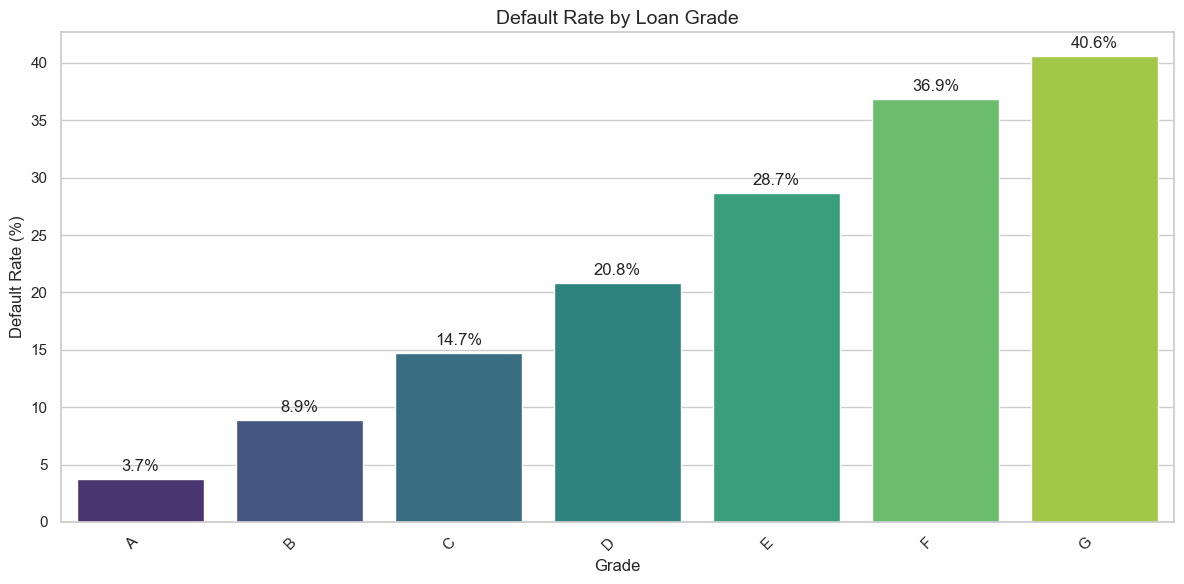

In [5]:
plot_default_rate_by_category(df, 'grade', title='Default Rate by Loan Grade')

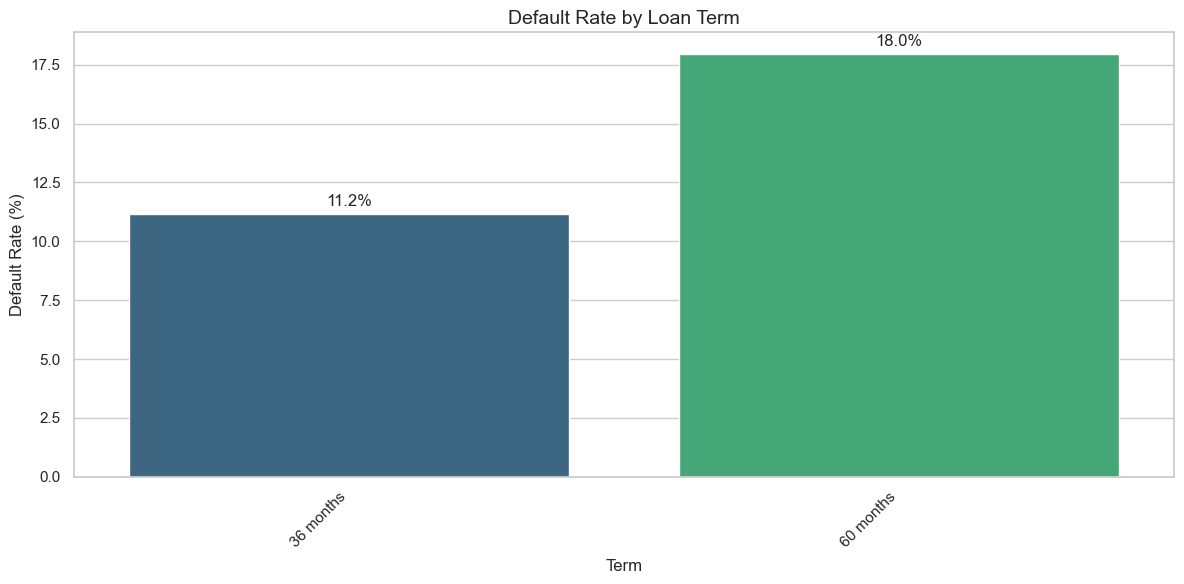

In [6]:
plot_default_rate_by_category(df, 'term', title='Default Rate by Loan Term')

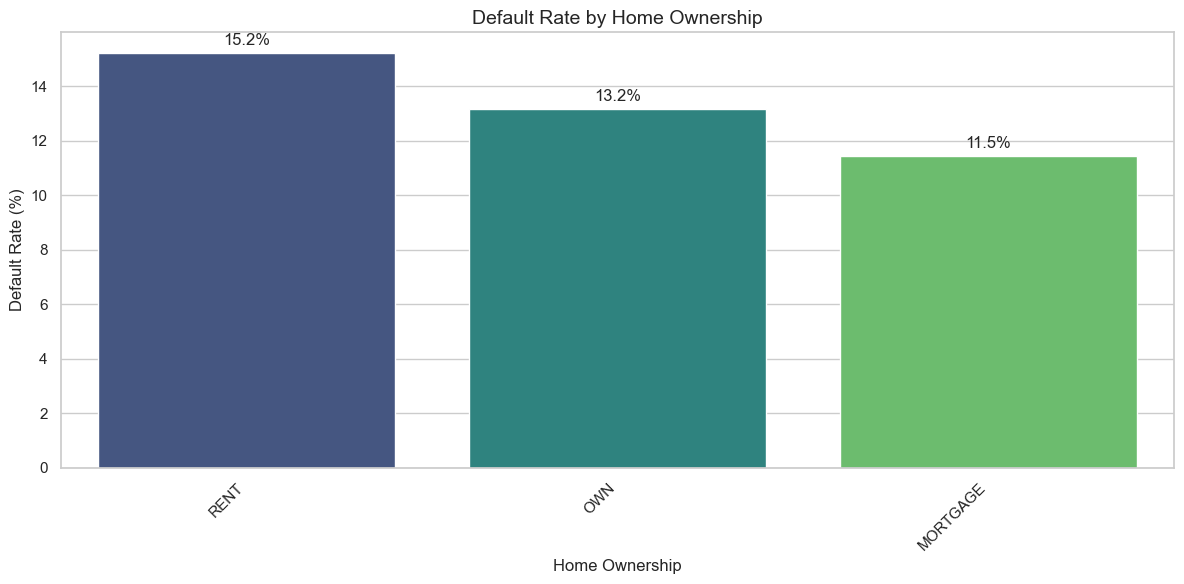

In [7]:
plot_default_rate_by_category(df, 'home_ownership', title='Default Rate by Home Ownership')

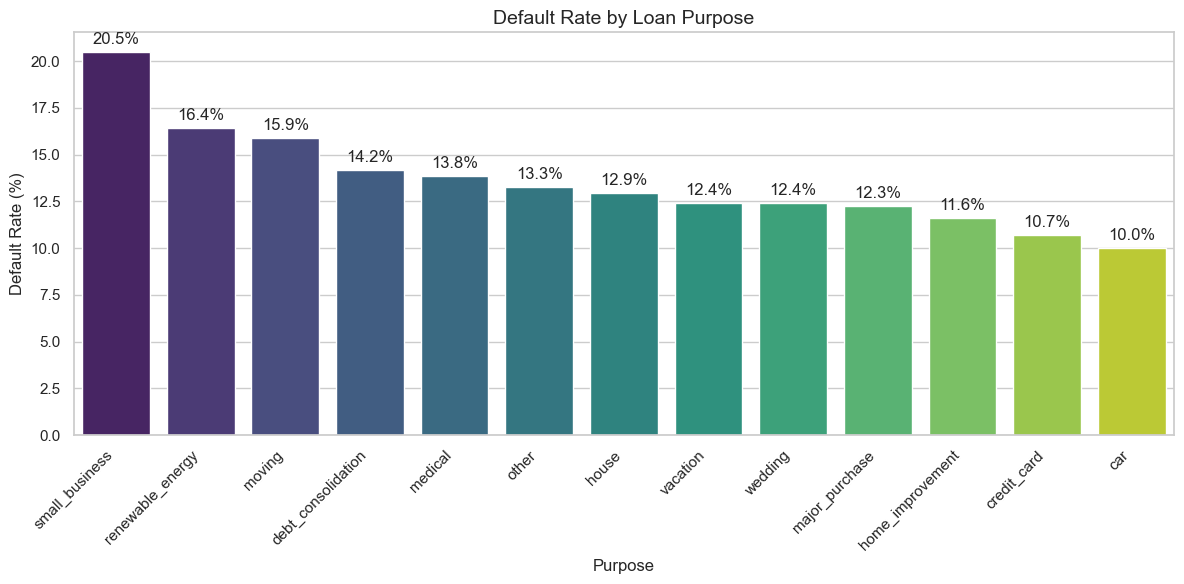

In [8]:
plot_default_rate_by_category(df, 'purpose', title='Default Rate by Loan Purpose')

## 4. Numerical Features vs. Target Variable
We will analyze continuous features like `int_rate`, `loan_amnt`, `dti`, and `annual_inc` grouped by our `Default` target. Since plotting boxplots for 2.26 million rows can be slow, we'll use a sample or `showfliers=False`.

In [9]:
def plot_num_vs_target(df, num_col, target_col='Default', title=None):
    plt.figure(figsize=(10, 6))
    
    # We set showfliers=False because large number of outliers will distort the plot 
    # and make rendering extremely slow for 2M rows.
    sns.boxplot(x=target_col, y=num_col, data=df, palette='Set2', showfliers=False)
    
    plt.title(title if title else f'{num_col} by Default Status', fontsize=14)
    plt.xlabel('Is Default?', fontsize=12)
    plt.ylabel(num_col.replace('_', ' ').title(), fontsize=12)
    plt.xticks([0, 1], ['No (Current/Paid)', 'Yes (Defaulted)'])
    plt.tight_layout()
    plt.show()

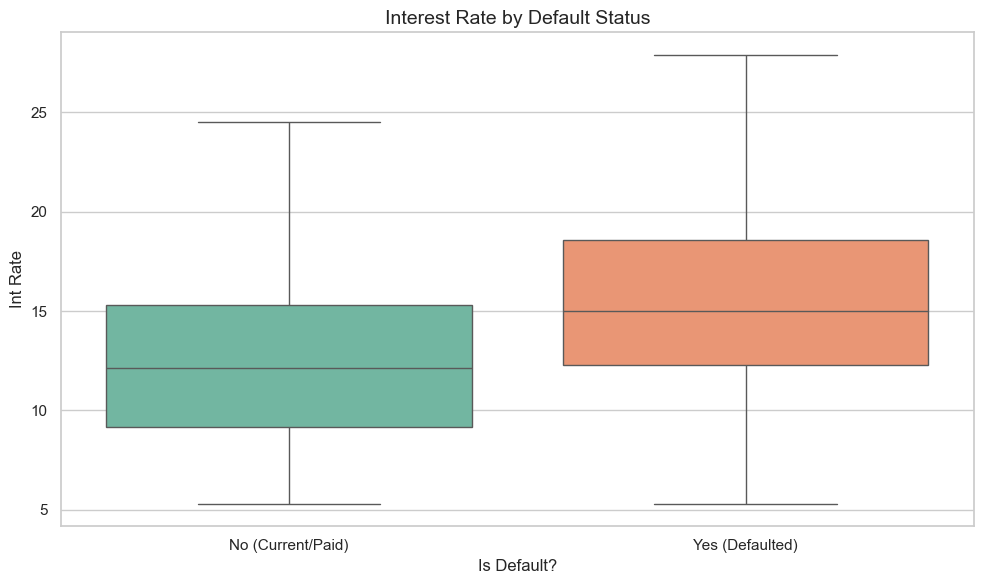

In [10]:
plot_num_vs_target(df, 'int_rate', title='Interest Rate by Default Status')

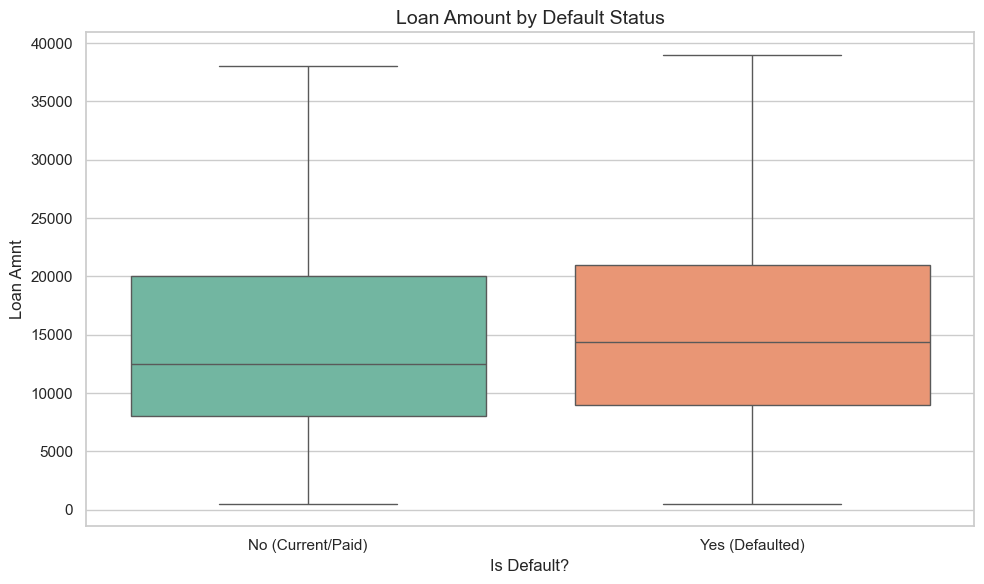

In [11]:
plot_num_vs_target(df, 'loan_amnt', title='Loan Amount by Default Status')

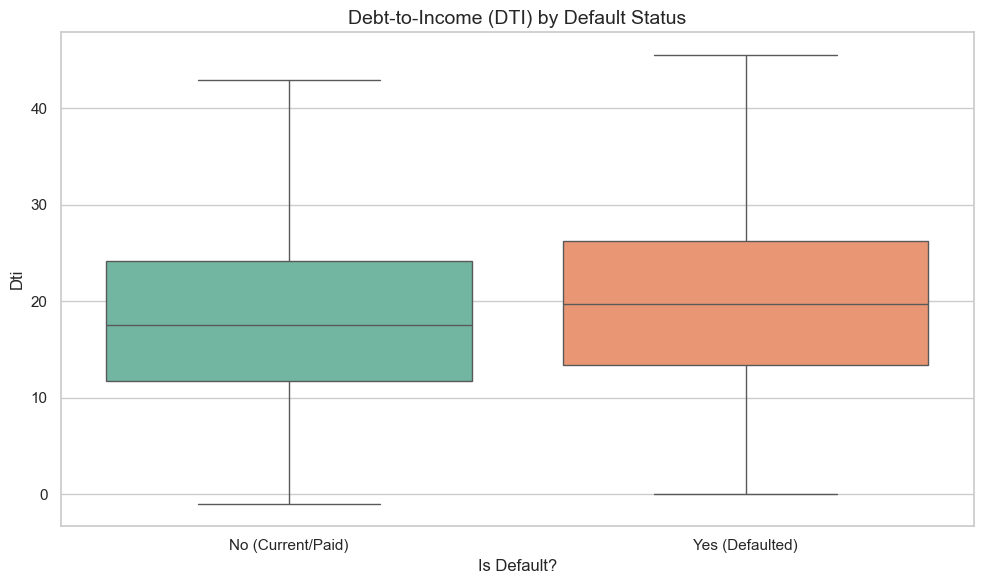

In [12]:
plot_num_vs_target(df, 'dti', title='Debt-to-Income (DTI) by Default Status')

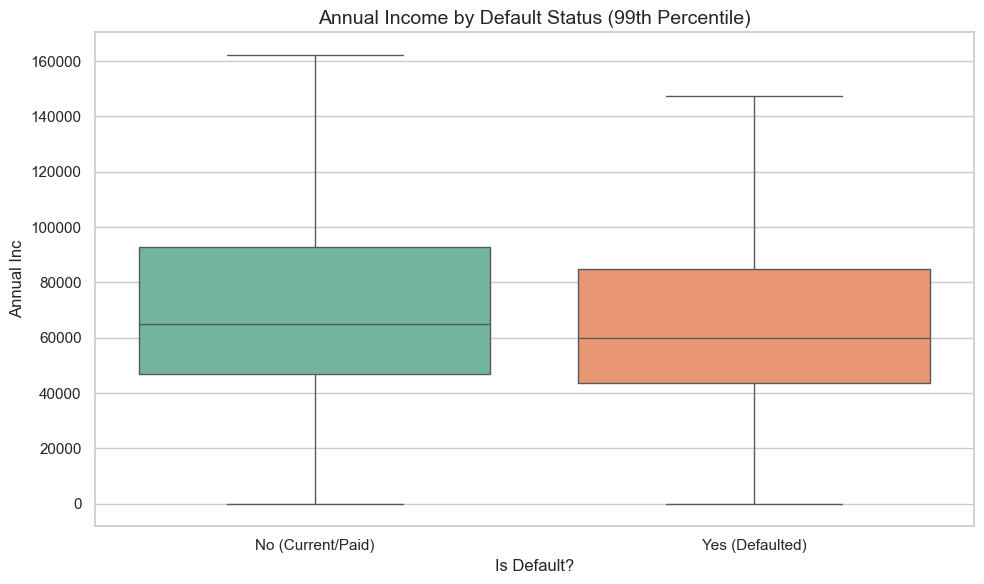

In [13]:
# For annual income, the distribution is heavily skewed, we clip extreme outliers for better visualization
df_income = df[df['annual_inc'] < df['annual_inc'].quantile(0.99)]
plot_num_vs_target(df_income, 'annual_inc', title='Annual Income by Default Status (99th Percentile)')